Варимнт 10. Параметры:
- Целевая переменная: `patient_recovery`
- Признаки: `age, treatment_days`
- Шум: 1.1
- % выбросов: 11%
- Амплитуда выбросов: ×5.5
- epsilon: 1.4
- loss : epsilon_insensitive
- Learning rate: 0.01
- Итерации SGD: 1300

ГЕНЕРАЦИЯ ДАННЫХ
Размер датасета: (500, 2)
Количество признаков: 2
Признаки: ['Age', 'Treatment_Days']
Истинные коэффициенты: age=0.80, treatment_days=-0.50
Истинный свободный член: 10.00
Количество выбросов: 55 (11.0%)

Первые 10 строк датасета:
         Age  Treatment_Days  Recovery_Time  Is_Outlier
0  69.973798       20.006953      57.640139       False
1  26.818996       14.941313      -8.148006        True
2  59.320040        9.959401      52.322969       False
3  53.982674       15.759840      46.599277       False
4  50.064371       13.777799      44.464766       False
5  56.495393       23.421262      19.906493        True
6  35.524015       22.197919      25.983628       False
7  53.429452       18.115963      44.270297       False
8  32.950967       15.945958      28.657766       False
9  72.268055        7.441366      64.370948       False

РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)

📊 Статистическое описание данных:
              Age  Treatment_Days  Recovery_Time
count  500.000000   

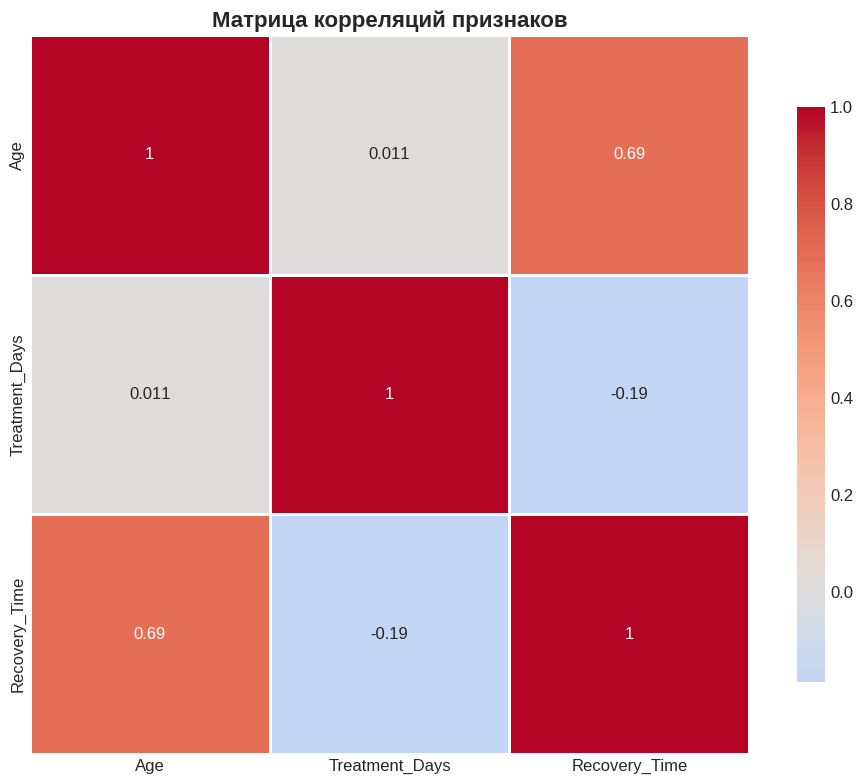


📈 Анализ корреляций:
Корреляция Age-Recovery: 0.692
Корреляция Treatment_Days-Recovery: -0.186


<Figure size 1200x1000 with 0 Axes>

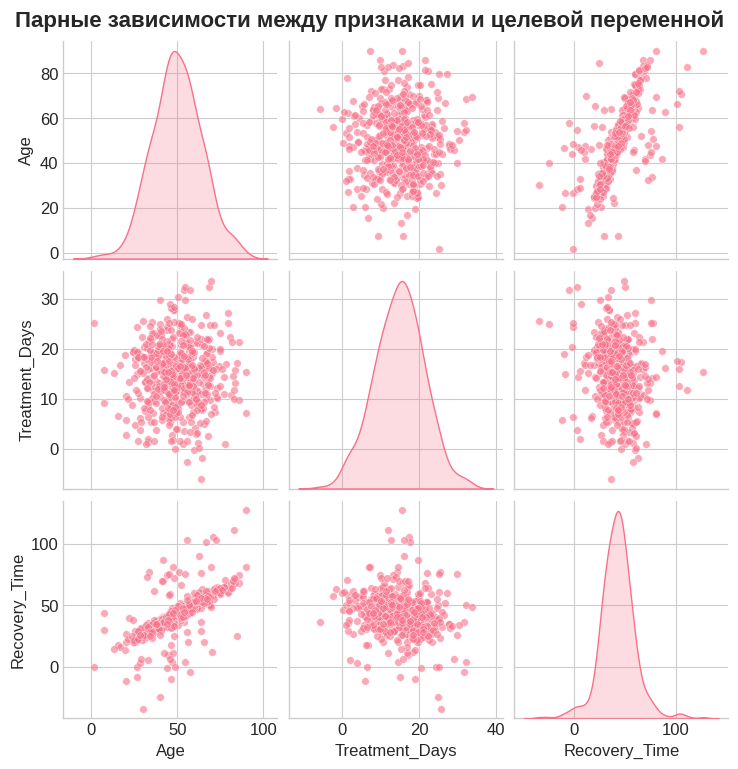

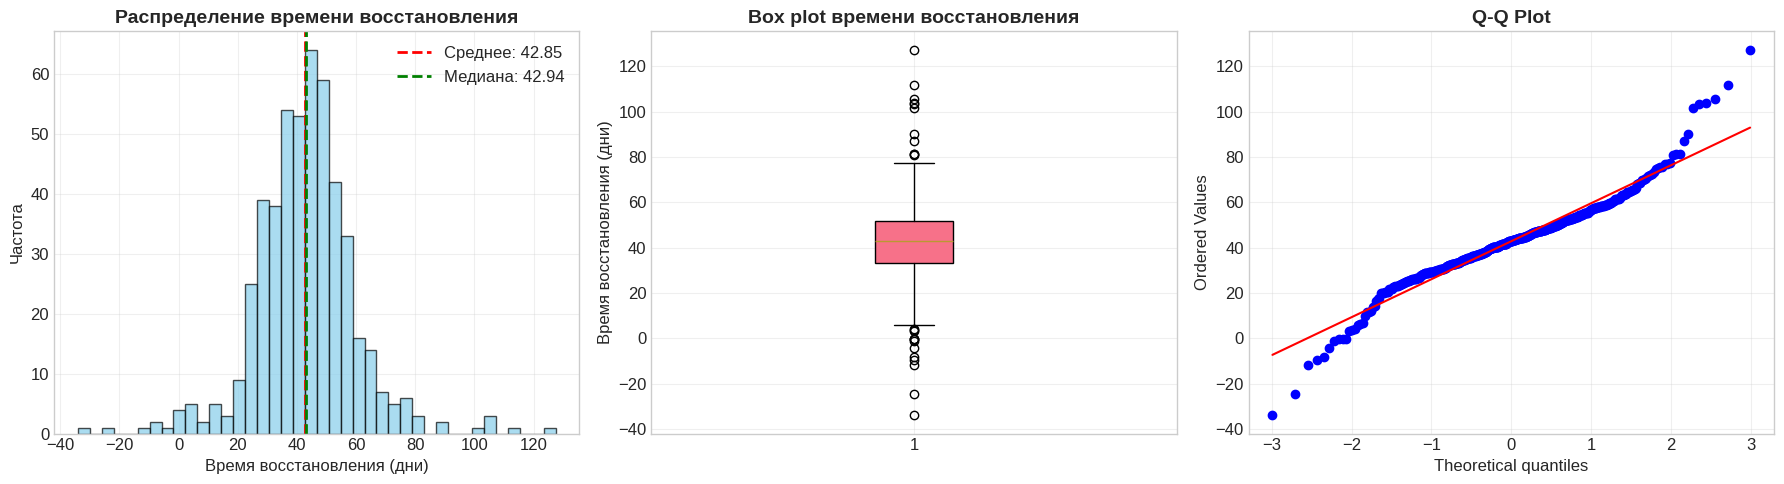

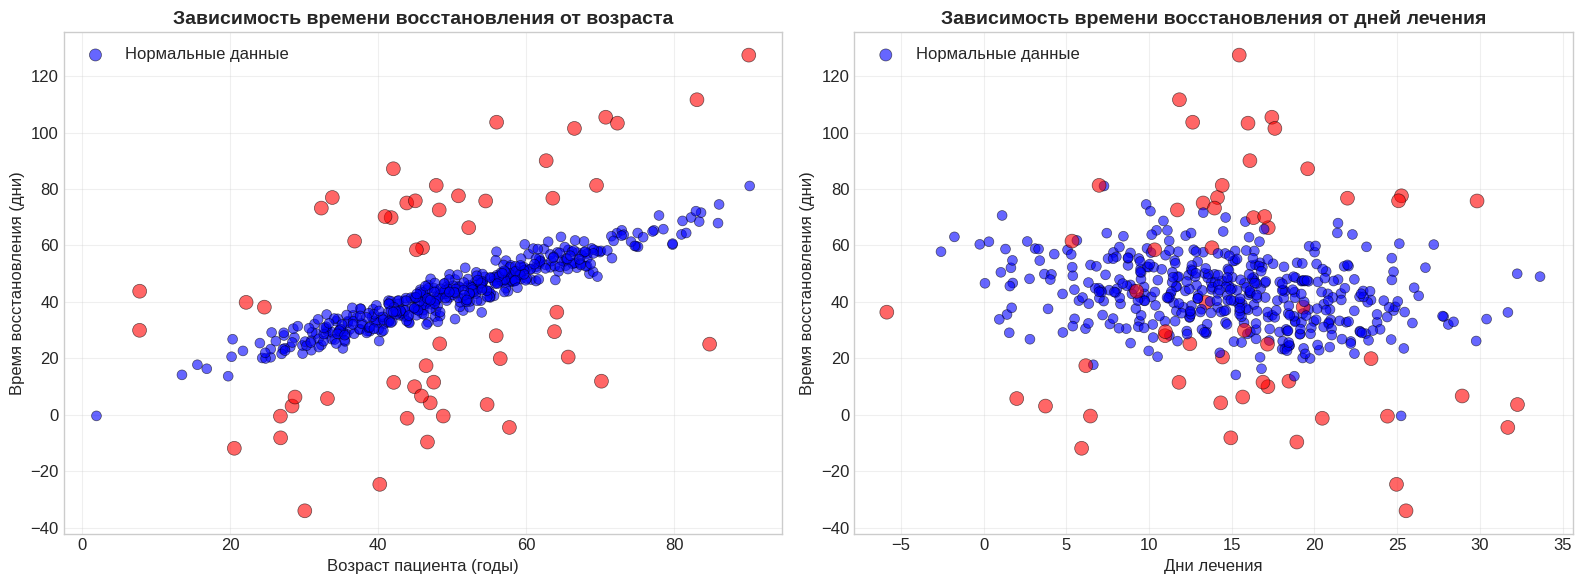


ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИРОВАНИЯ
Обучающая выборка: (350, 2)
Тестовая выборка: (150, 2)

✓ Масштабирование выполнено!
Среднее после масштабирования: [ 0. -0.]
Стандартное отклонение: [1. 1.]

ОБУЧЕНИЕ МОДЕЛЕЙ

📈 Обучение LinearRegression (MSE)...
✓ Время обучения: 0.0058 сек
  Coef: [11.6523 -3.7213]
  Intercept: 42.7283

🛡️ Обучение HuberRegressor (epsilon=1.4)...
✓ Время обучения: 0.0543 сек
  Coef: [11.4657 -3.2896]
  Intercept: 42.2014

⚡ Обучение SGDRegressor (loss=epsilon_insensitive, lr=0.01)...
✓ Время обучения: 0.0070 сек
  Coef: [11.501  -3.2858]
  Intercept: 42.1300

СРАВНЕНИЕ С ИСТИННЫМИ КОЭФФИЦИЕНТАМИ
           Модель  Age_coef  Treatment_Days_coef  Intercept
Истинные значения    0.8000              -0.5000    10.0000
 LinearRegression   11.6523              -3.7213    42.7283
   HuberRegressor   11.4657              -3.2896    42.2014
     SGDRegressor   11.5010              -3.2858    42.1300

ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ

📊 Метрики качества на тестовой выборке:
        

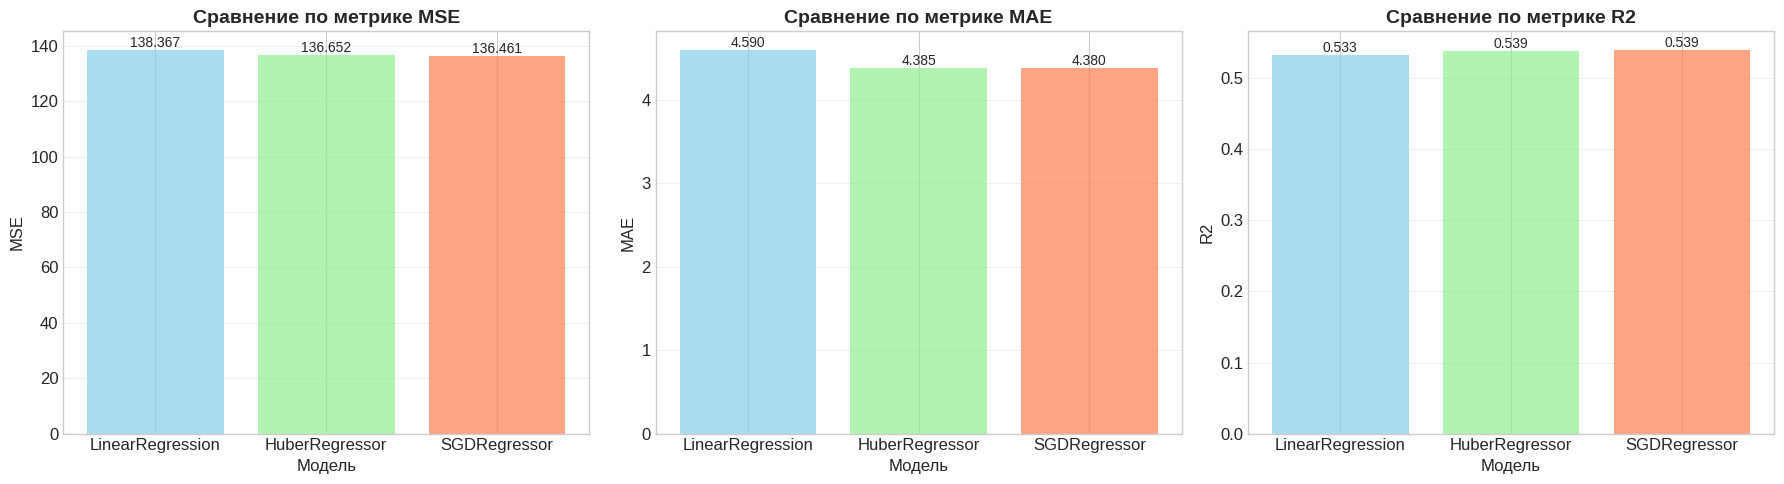


ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ МОДЕЛЕЙ


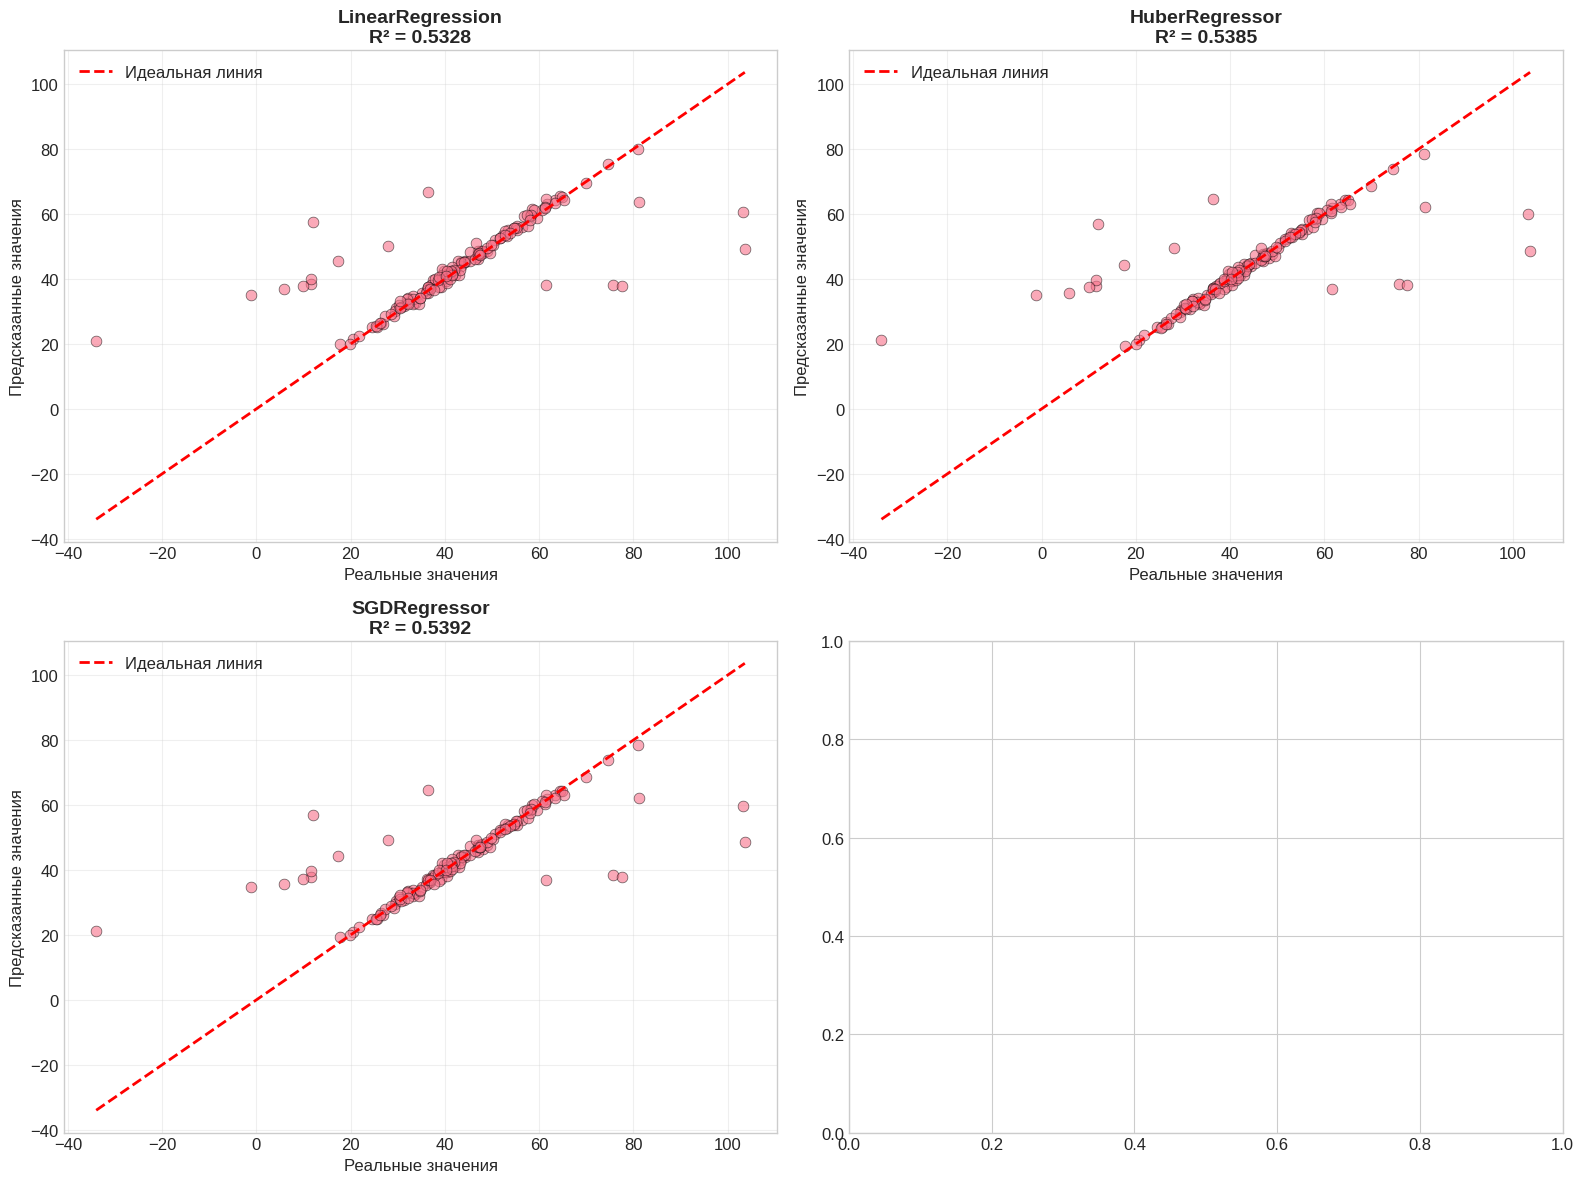


АНАЛИЗ ОСТАТКОВ МОДЕЛЕЙ


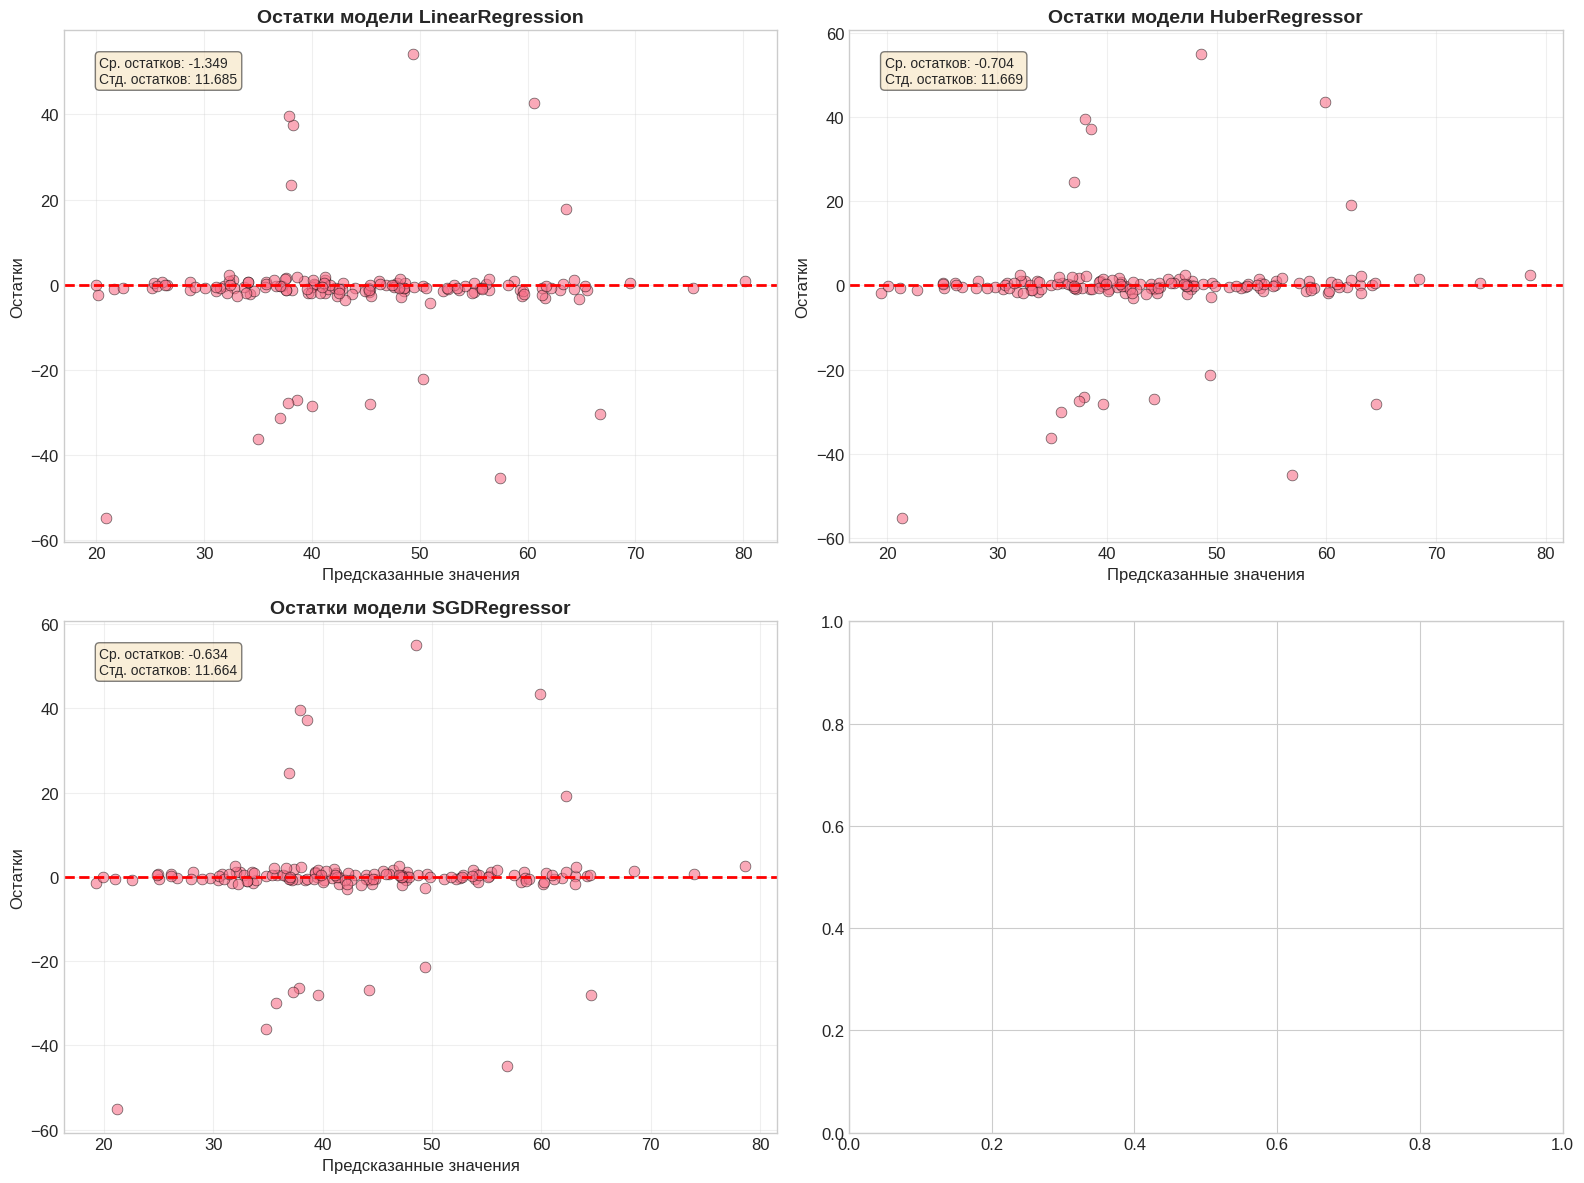

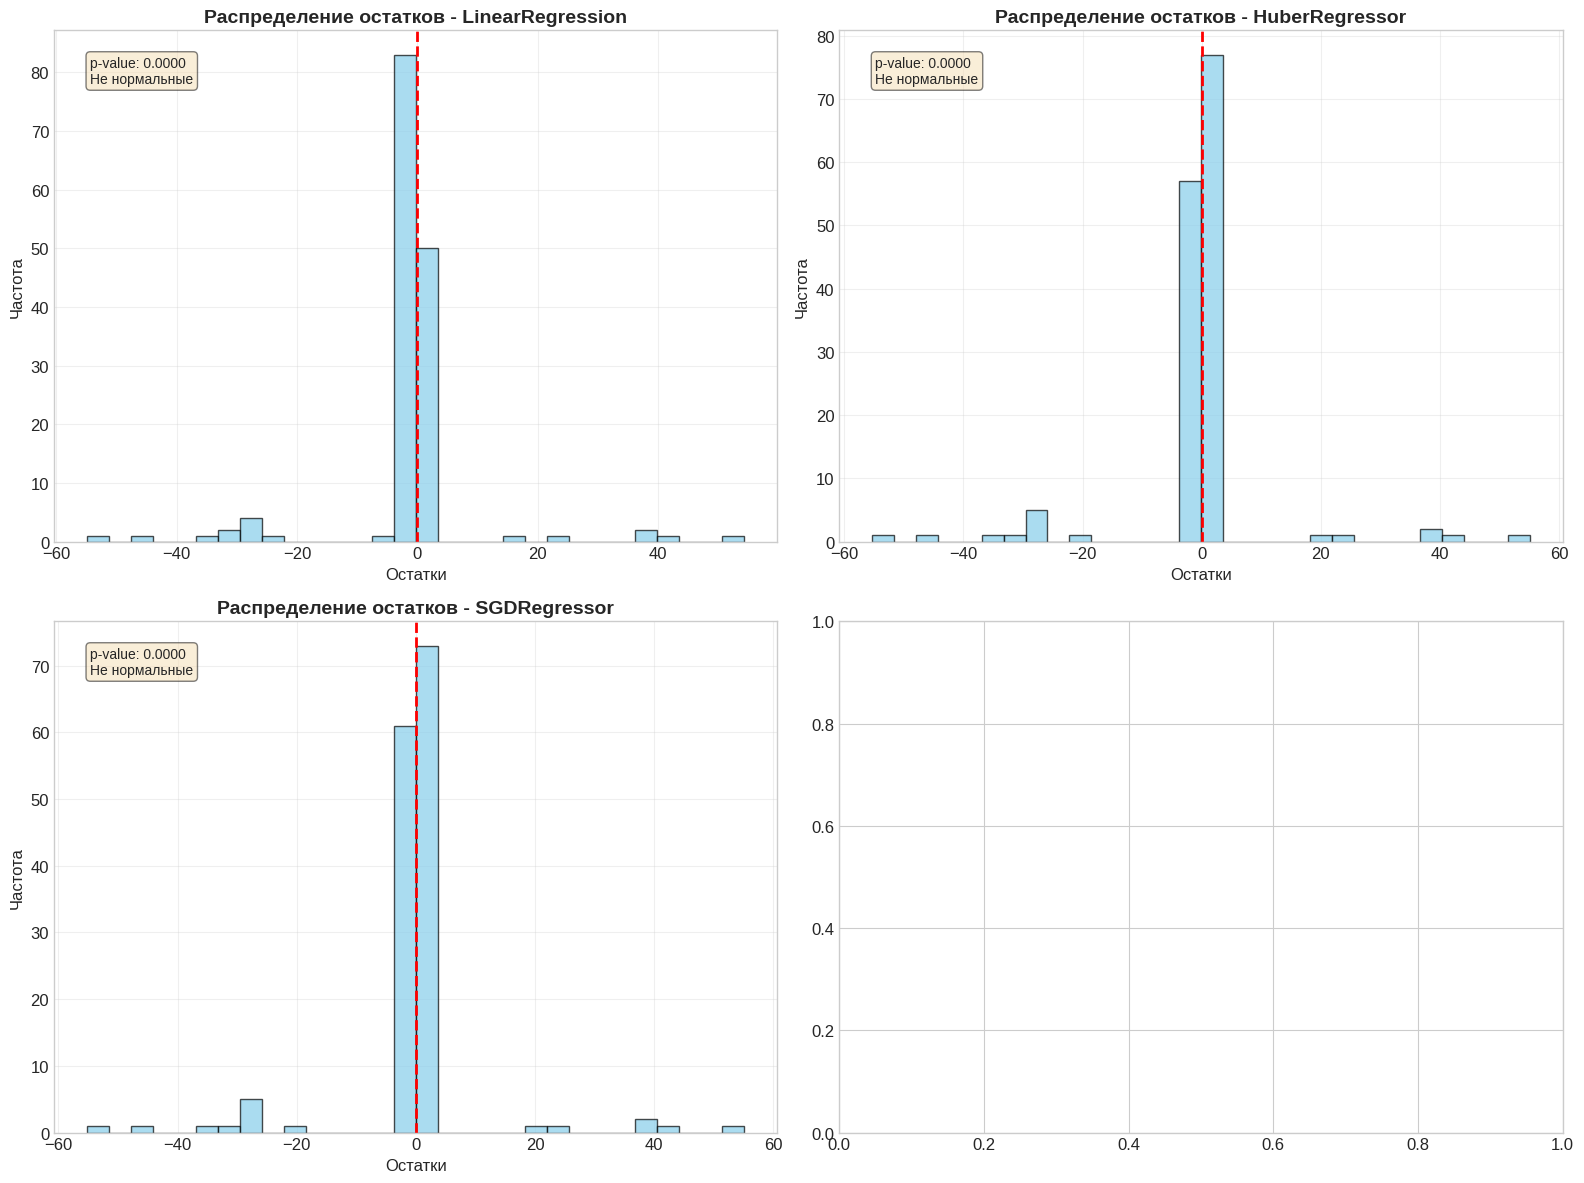


АНАЛИЗ УСТОЙЧИВОСТИ К ВЫБРОСАМ

📊 Влияние доли выбросов на качество моделей:
 Outlier_Fraction  LR_R2  Huber_R2
             0.00 0.9917    0.9917
             0.05 0.6957    0.6947
             0.11 0.5158    0.5150
             0.15 0.4170    0.4155
             0.20 0.3389    0.3376
             0.25 0.2690    0.2651


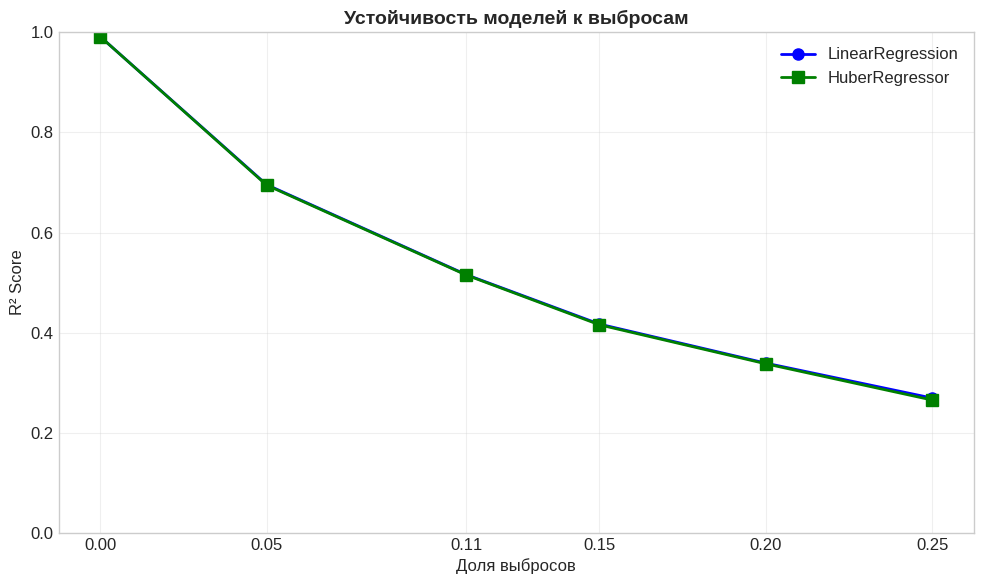


ИССЛЕДОВАНИЕ ВЛИЯНИЯ ПАРАМЕТРА EPSILON
📌 В HuberRegressor параметр epsilon должен быть >= 1.0
Исследуем значения от 1.0 до 3.0

Начинаем эксперимент:
--------------------------------------------------
Пробуем epsilon = 1.0... ✓ R2 = 0.538
Пробуем epsilon = 1.14... ✓ R2 = 0.538
Пробуем epsilon = 1.29... ✓ R2 = 0.538
Пробуем epsilon = 1.43... ✓ R2 = 0.539
Пробуем epsilon = 1.57... ✓ R2 = 0.539
Пробуем epsilon = 1.71... ✓ R2 = 0.539
Пробуем epsilon = 1.86... ✓ R2 = 0.539
Пробуем epsilon = 2.0... ✓ R2 = 0.538
Пробуем epsilon = 2.14... ✓ R2 = 0.538
Пробуем epsilon = 2.29... ✓ R2 = 0.538
Пробуем epsilon = 2.43... ✓ R2 = 0.538
Пробуем epsilon = 2.57... ✓ R2 = 0.538
Пробуем epsilon = 2.71... ✓ R2 = 0.538
Пробуем epsilon = 2.86... ✓ R2 = 0.537
Пробуем epsilon = 3.0... ✓ R2 = 0.534
--------------------------------------------------

📊 Таблица результатов:
------------------------------------------------------------
 Epsilon   |    MSE     |    MAE     |     R2    
------------------------------

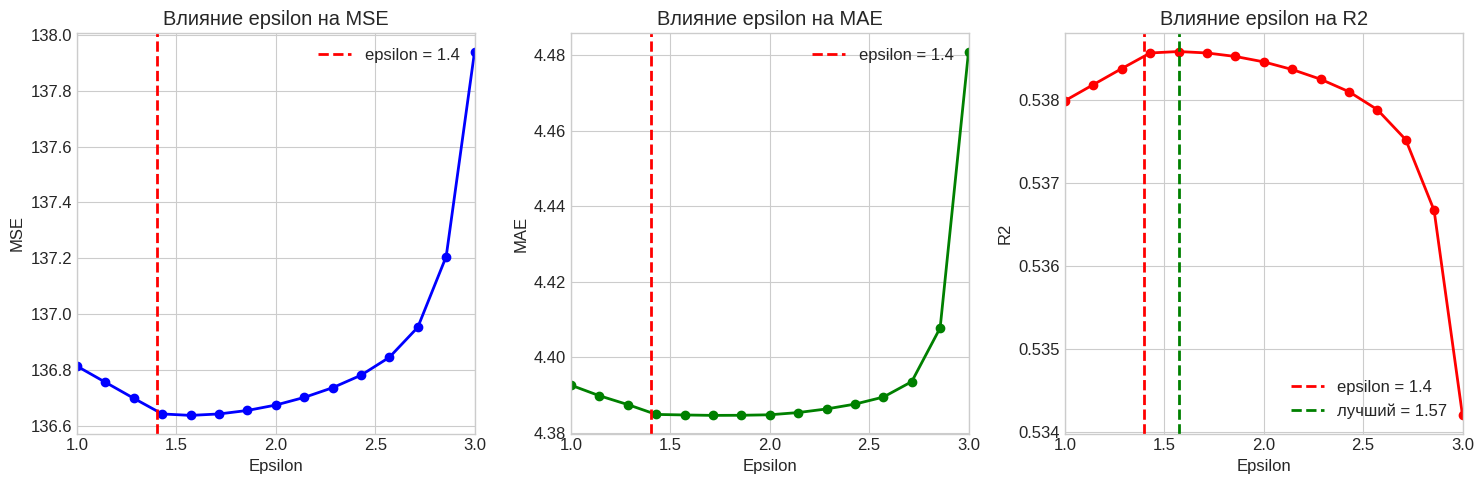

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
from sklearn.linear_model import LinearRegression, HuberRegressor, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import time
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12


# 2. ФУНКЦИЯ ГЕНЕРАЦИИ ДАННЫХ


def generate_dataset(n_samples=500, n_features=2, noise_std=1.1,
                     outlier_fraction=0.11, outlier_multiplier=5.5,
                     random_seed=10):
    """
    Генерация синтетического датасета для линейной регрессии
    Параметры соответствуют варианту 10
    """
    if random_seed is not None:
        np.random.seed(random_seed)

    # Генерация признаков (возраст и дни лечения)
    X = np.random.randn(n_samples, n_features)

    # Масштабируем признаки для реалистичности
    # Возраст: от 20 до 80 лет
    X[:, 0] = X[:, 0] * 15 + 50  # age
    # Дни лечения: от 1 до 30 дней
    X[:, 1] = X[:, 1] * 7 + 15   # treatment_days

    # С возрастом время восстановления растет, с днями лечения - падает
    true_coef = np.array([0.8, -0.5])  # age влияет положительно, treatment_days - отрицательно
    true_intercept = 10  # базовое время восстановления

    # Генерация целевой переменной
    y = X @ true_coef + true_intercept + np.random.randn(n_samples) * noise_std

    # Добавление выбросов (пациенты с осложнениями)
    n_outliers = int(n_samples * outlier_fraction)
    outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)
    y[outlier_idx] += np.random.choice([-1, 1], n_outliers) * \
                      np.random.uniform(3, 10, n_outliers) * outlier_multiplier

    return X, y, true_coef, true_intercept, outlier_idx

# Генерируем данные
X, y, true_coef, true_intercept, outlier_idx = generate_dataset()

# Создаём DataFrame для удобства
feature_names = ['Age', 'Treatment_Days']
df = pd.DataFrame(X, columns=feature_names)
df['Recovery_Time'] = y
df['Is_Outlier'] = False
df.iloc[outlier_idx, -1] = True

print("=" * 70)
print("ГЕНЕРАЦИЯ ДАННЫХ")
print("=" * 70)
print(f"Размер датасета: {X.shape}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Признаки: {feature_names}")
print(f"Истинные коэффициенты: age={true_coef[0]:.2f}, treatment_days={true_coef[1]:.2f}")
print(f"Истинный свободный член: {true_intercept:.2f}")
print(f"Количество выбросов: {len(outlier_idx)} ({len(outlier_idx)/len(y)*100:.1f}%)")
print("\nПервые 10 строк датасета:")
print(df.head(10))


# 3. РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)


print("\n" + "=" * 70)
print("РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)")
print("=" * 70)

# Статистическое описание данных
print("\n📊 Статистическое описание данных:")
print(df.describe())

# 3.1 Матрица корреляций
plt.figure(figsize=(10, 8))
correlation_matrix = df[['Age', 'Treatment_Days', 'Recovery_Time']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📈 Анализ корреляций:")
print(f"Корреляция Age-Recovery: {correlation_matrix.loc['Age', 'Recovery_Time']:.3f}")
print(f"Корреляция Treatment_Days-Recovery: {correlation_matrix.loc['Treatment_Days', 'Recovery_Time']:.3f}")

# 3.2 Pairplot для визуализации зависимостей
plt.figure(figsize=(12, 10))
g = sns.pairplot(df[['Age', 'Treatment_Days', 'Recovery_Time']],
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30})
g.fig.suptitle('Парные зависимости между признаками и целевой переменной',
               y=1.02, fontsize=16, fontweight='bold')
plt.show()

# 3.3 Анализ распределения целевой переменной
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма распределения Recovery Time
axes[0].hist(y, bins=40, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(np.mean(y), color='red', linestyle='--', linewidth=2, label=f'Среднее: {np.mean(y):.2f}')
axes[0].axvline(np.median(y), color='green', linestyle='--', linewidth=2, label=f'Медиана: {np.median(y):.2f}')
axes[0].set_xlabel('Время восстановления (дни)', fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)
axes[0].set_title('Распределение времени восстановления', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot для выявления выбросов
axes[1].boxplot(y, vert=True, patch_artist=True)
axes[1].set_ylabel('Время восстановления (дни)', fontsize=12)
axes[1].set_title('Box plot времени восстановления', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Q-Q plot для проверки нормальности
stats.probplot(y, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3.4 Визуализация выбросов
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot с выделением выбросов
colors = ['red' if is_outlier else 'blue' for is_outlier in df['Is_Outlier']]
sizes = [100 if is_outlier else 50 for is_outlier in df['Is_Outlier']]

axes[0].scatter(df['Age'], df['Recovery_Time'], c=colors, s=sizes, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Возраст пациента (годы)', fontsize=12)
axes[0].set_ylabel('Время восстановления (дни)', fontsize=12)
axes[0].set_title('Зависимость времени восстановления от возраста', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(['Нормальные данные', 'Выбросы'], loc='upper left')

axes[1].scatter(df['Treatment_Days'], df['Recovery_Time'], c=colors, s=sizes, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('Дни лечения', fontsize=12)
axes[1].set_ylabel('Время восстановления (дни)', fontsize=12)
axes[1].set_title('Зависимость времени восстановления от дней лечения', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(['Нормальные данные', 'Выбросы'], loc='upper left')

plt.tight_layout()
plt.show()

# 4. ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИРОВАНИЯ


print("\n" + "=" * 70)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИРОВАНИЯ")
print("=" * 70)

# Разделение на обучающую и тестовую выборки (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

# Масштабирование признаков (важно для SGDRegressor!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Масштабирование выполнено!")
print(f"Среднее после масштабирования: {np.mean(X_train_scaled, axis=0).round(2)}")
print(f"Стандартное отклонение: {np.std(X_train_scaled, axis=0).round(2)}")


# 5. ОБУЧЕНИЕ МОДЕЛЕЙ

print("\n" + "=" * 70)
print("ОБУЧЕНИЕ МОДЕЛЕЙ")
print("=" * 70)

models = {}
results = []

# 5.1 LinearRegression (минимизация MSE)
print("\n📈 Обучение LinearRegression (MSE)...")
start_time = time.time()
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

models['LinearRegression'] = model_lr
print(f"✓ Время обучения: {train_time:.4f} сек")
print(f"  Coef: {model_lr.coef_.round(4)}")
print(f"  Intercept: {model_lr.intercept_:.4f}")

# 5.2 HuberRegressor (робастная регрессия)
print("\n🛡️ Обучение HuberRegressor (epsilon=1.4)...")
start_time = time.time()
model_huber = HuberRegressor(epsilon=1.4, max_iter=1000)
model_huber.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

models['HuberRegressor'] = model_huber
print(f"✓ Время обучения: {train_time:.4f} сек")
print(f"  Coef: {model_huber.coef_.round(4)}")
print(f"  Intercept: {model_huber.intercept_:.4f}")

# 5.3 SGDRegressor с epsilon_insensitive loss (ИСПРАВЛЕНО)
print("\n⚡ Обучение SGDRegressor (loss=epsilon_insensitive, lr=0.01)...")
start_time = time.time()
model_sgd = SGDRegressor(
    loss='epsilon_insensitive',
    epsilon=1.4,
    learning_rate='constant',
    eta0=0.01,
    max_iter=1300,
    random_state=42,
    tol=1e-3  # Добавляем допуск для ранней остановки
)
model_sgd.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

models['SGDRegressor'] = model_sgd
print(f"✓ Время обучения: {train_time:.4f} сек")
print(f"  Coef: {model_sgd.coef_.round(4)}")
# ИСПРАВЛЕНИЕ: intercept у SGDRegressor - это массив, берем первый элемент
print(f"  Intercept: {model_sgd.intercept_[0]:.4f}")

# Сравнение с истинными коэффициентами
print("\n" + "=" * 70)
print("СРАВНЕНИЕ С ИСТИННЫМИ КОЭФФИЦИЕНТАМИ")
print("=" * 70)

# Для SGD intercept может быть массивом, поэтому обрабатываем отдельно
sgd_intercept = model_sgd.intercept_[0] if hasattr(model_sgd.intercept_, '__len__') else model_sgd.intercept_

coef_comparison = pd.DataFrame({
    'Модель': ['Истинные значения', 'LinearRegression', 'HuberRegressor', 'SGDRegressor'],
    'Age_coef': [true_coef[0], model_lr.coef_[0], model_huber.coef_[0], model_sgd.coef_[0]],
    'Treatment_Days_coef': [true_coef[1], model_lr.coef_[1], model_huber.coef_[1], model_sgd.coef_[1]],
    'Intercept': [true_intercept, model_lr.intercept_, model_huber.intercept_, sgd_intercept]
})
print(coef_comparison.round(4).to_string(index=False))


# 6. ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ


print("\n" + "=" * 70)
print("ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ")
print("=" * 70)

def evaluate_model(model, X_test, y_test, name):
    """Оценка модели по различным метрикам"""
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mse)

    return {
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# Оцениваем все модели
for name, model in models.items():
    results.append(evaluate_model(model, X_test_scaled, y_test, name))

# Создаём DataFrame с результатами
results_df = pd.DataFrame(results)
print("\n📊 Метрики качества на тестовой выборке:")
print(results_df.round(4).to_string(index=False))

# Визуализация сравнения метрик
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['MSE', 'MAE', 'R2']
colors = ['skyblue', 'lightgreen', 'coral', 'gold']

for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors, alpha=0.7)
    ax.set_xlabel('Модель', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'Сравнение по метрике {metric}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Добавляем значения на столбцы
    for bar, value in zip(bars, results_df[metric]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


# 7. ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ


print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ МОДЕЛЕЙ")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)

    # Scatter plot предсказанных vs реальных значений
    axes[idx].scatter(y_test, y_pred, alpha=0.6, edgecolors='black', linewidth=0.5, s=60)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                   'r--', linewidth=2, label='Идеальная линия')
    axes[idx].set_xlabel('Реальные значения', fontsize=12)
    axes[idx].set_ylabel('Предсказанные значения', fontsize=12)
    axes[idx].set_title(f'{name}\nR² = {r2_score(y_test, y_pred):.4f}', fontsize=14, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 8. АНАЛИЗ ОСТАТКОВ


print("\n" + "=" * 70)
print("АНАЛИЗ ОСТАТКОВ МОДЕЛЕЙ")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    residuals = y_test - y_pred

    # Residual plot
    axes[idx].scatter(y_pred, residuals, alpha=0.6, edgecolors='black', linewidth=0.5, s=60)
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_xlabel('Предсказанные значения', fontsize=12)
    axes[idx].set_ylabel('Остатки', fontsize=12)
    axes[idx].set_title(f'Остатки модели {name}', fontsize=14, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

    # Добавляем статистику
    axes[idx].text(0.05, 0.95, f'Ср. остатков: {np.mean(residuals):.3f}\nСтд. остатков: {np.std(residuals):.3f}',
                   transform=axes[idx].transAxes, fontsize=10,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Гистограммы распределения остатков
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    residuals = y_test - y_pred

    axes[idx].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_xlabel('Остатки', fontsize=12)
    axes[idx].set_ylabel('Частота', fontsize=12)
    axes[idx].set_title(f'Распределение остатков - {name}', fontsize=14, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

    # Тест на нормальность
    stat, p_value = shapiro(residuals[:100])  # Берем подвыборку
    axes[idx].text(0.05, 0.95, f'p-value: {p_value:.4f}\n{"Нормальные" if p_value>0.05 else "Не нормальные"}',
                   transform=axes[idx].transAxes, fontsize=10,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


# 9. АНАЛИЗ УСТОЙЧИВОСТИ К ВЫБРОСАМ


print("\n" + "=" * 70)
print("АНАЛИЗ УСТОЙЧИВОСТИ К ВЫБРОСАМ")
print("=" * 70)

# Создаем данные с разным процентом выбросов
outlier_fractions = [0, 0.05, 0.11, 0.15, 0.2, 0.25]
robustness_results = []

for frac in outlier_fractions:
    # Генерируем данные с текущим процентом выбросов
    X_temp, y_temp, _, _, _ = generate_dataset(
        outlier_fraction=frac,
        outlier_multiplier=5.5,
        random_seed=10
    )

    # Масштабируем
    scaler_temp = StandardScaler()
    X_temp_scaled = scaler_temp.fit_transform(X_temp)

    # Обучаем модели
    lr_temp = LinearRegression().fit(X_temp_scaled, y_temp)
    huber_temp = HuberRegressor(epsilon=1.4).fit(X_temp_scaled, y_temp)

    # Оцениваем (используем те же данные для простоты)
    robustness_results.append({
        'Outlier_Fraction': frac,
        'LR_R2': r2_score(y_temp, lr_temp.predict(X_temp_scaled)),
        'Huber_R2': r2_score(y_temp, huber_temp.predict(X_temp_scaled))
    })

robustness_df = pd.DataFrame(robustness_results)
print("\n📊 Влияние доли выбросов на качество моделей:")
print(robustness_df.round(4).to_string(index=False))

# Визуализация устойчивости
plt.figure(figsize=(10, 6))
plt.plot(robustness_df['Outlier_Fraction'], robustness_df['LR_R2'],
         'o-', linewidth=2, markersize=8, label='LinearRegression', color='blue')
plt.plot(robustness_df['Outlier_Fraction'], robustness_df['Huber_R2'],
         's-', linewidth=2, markersize=8, label='HuberRegressor', color='green')
plt.xlabel('Доля выбросов', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Устойчивость моделей к выбросам', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(outlier_fractions)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# 10. ИССЛЕДОВАНИЕ ВЛИЯНИЯ ПАРАМЕТРА EPSILON


print("\n" + "=" * 70)
print("ИССЛЕДОВАНИЕ ВЛИЯНИЯ ПАРАМЕТРА EPSILON")
print("=" * 70)

print("📌 В HuberRegressor параметр epsilon должен быть >= 1.0")
print("Исследуем значения от 1.0 до 3.0\n")

epsilon_values = np.linspace(1.0, 3.0, 15)

epsilon_list = []
mse_list = []
mae_list = []
r2_list = []

print("Начинаем эксперимент:")
print("-" * 50)

for eps in epsilon_values:
    eps_rounded = round(eps, 2)
    print(f"Пробуем epsilon = {eps_rounded}...", end=" ")

    try:
        huber_model = HuberRegressor(epsilon=eps, max_iter=1000)
        huber_model.fit(X_train_scaled, y_train)

        y_predicted = huber_model.predict(X_test_scaled)

        current_mse = mean_squared_error(y_test, y_predicted)
        current_mae = mean_absolute_error(y_test, y_predicted)
        current_r2 = r2_score(y_test, y_predicted)

        epsilon_list.append(eps)
        mse_list.append(current_mse)
        mae_list.append(current_mae)
        r2_list.append(current_r2)

        print(f"✓ R2 = {current_r2:.3f}")

    except Exception as error:
        print(f"✗ Ошибка: {error}")

print("-" * 50)

print("\n📊 Таблица результатов:")
print("-" * 60)
print(f"{'Epsilon':^10} | {'MSE':^10} | {'MAE':^10} | {'R2':^10}")
print("-" * 60)

for i in range(len(epsilon_list)):
    print(f"{epsilon_list[i]:^10.2f} | {mse_list[i]:^10.3f} | {mae_list[i]:^10.3f} | {r2_list[i]:^10.3f}")
print("-" * 60)

best_index = 0
best_r2 = r2_list[0]

for i in range(len(r2_list)):
    if r2_list[i] > best_r2:
        best_r2 = r2_list[i]
        best_index = i

best_epsilon = epsilon_list[best_index]

print(f"\n🏆 Лучший результат:")
print(f"   Epsilon = {best_epsilon:.2f}")
print(f"   R2 = {best_r2:.3f}")
print(f"   MSE = {mse_list[best_index]:.3f}")
print(f"   MAE = {mae_list[best_index]:.3f}")

print("\n📈 Строим графики влияния epsilon...")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(epsilon_list, mse_list, 'bo-', linewidth=2, markersize=6)
axes[0].axvline(x=1.4, color='red', linestyle='--', linewidth=2, label='epsilon = 1.4')
axes[0].set_xlabel('Epsilon')
axes[0].set_ylabel('MSE')
axes[0].set_title('Влияние epsilon на MSE')
axes[0].legend()
axes[0].grid(True)
axes[0].set_xlim(1.0, 3.0)

axes[1].plot(epsilon_list, mae_list, 'go-', linewidth=2, markersize=6)
axes[1].axvline(x=1.4, color='red', linestyle='--', linewidth=2, label='epsilon = 1.4')
axes[1].set_xlabel('Epsilon')
axes[1].set_ylabel('MAE')
axes[1].set_title('Влияние epsilon на MAE')
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlim(1.0, 3.0)

axes[2].plot(epsilon_list, r2_list, 'ro-', linewidth=2, markersize=6)
axes[2].axvline(x=1.4, color='red', linestyle='--', linewidth=2, label='epsilon = 1.4')
axes[2].axvline(x=best_epsilon, color='green', linestyle='--', linewidth=2, label=f'лучший = {best_epsilon:.2f}')
axes[2].set_xlabel('Epsilon')
axes[2].set_ylabel('R2')
axes[2].set_title('Влияние epsilon на R2')
axes[2].legend()
axes[2].grid(True)
axes[2].set_xlim(1.0, 3.0)

plt.tight_layout()
plt.show()
